# Car Counting Between Two Gates

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ziadelh/traffic-car-tracking/blob/main/car_counting.ipynb)

Counts the cars that drive from the city centre to downtown in two recordings from the same traffic camera. The counting uses frame differencing and background subtraction, a tracker, and two virtual gates:

- cars come from the left along the main street and cross the **blue entry gate**,
- they then turn up the side street and cross the **yellow exit gate**.

A car is counted once, when it has crossed the entry gate and then the exit gate within a time window and has travelled far enough across the frame. The design choices that make the count reliable:

1. **The direction filter applies only at the entry gate.** Tracks must be moving mostly sideways to trip the blue gate, but a car crossing the yellow gate is turning up the side street and moves steeply, so no direction filter is applied there.
2. **The yellow gate starts past the crosswalk** (0.70 of the frame width), so people and cyclists on the crosswalk are not counted.
3. **One car, one count.** A car that is split into two tracks crosses the gate twice within a moment, so two counts within 1 second and 100 pixels of each other are treated as the same car.
4. **A short memory of recently lost tracks ("ghosts")** lets a track that was dropped be picked up again.

The result is a table with the total number of cars and the cars per minute for each recording, followed by a check against a count made by hand.

## Setup

In [1]:
import os, urllib.request

# The traffic recordings are large, so they are published as a release asset instead of being stored in the repository
BASE_URL = "https://github.com/ziadelh/traffic-car-tracking/releases/download/data-v1/"
for name in ['Traffic_Laramie_1.mp4', 'Traffic_Laramie_2.mp4']:
    if not os.path.exists(name):
        print("Downloading", name, "...")
        urllib.request.urlretrieve(BASE_URL + name, name)
print("Videos ready.")

Videos ready.


### Cell 1  Imports and Global Parameters
This cell imports required libraries and defines all global constants.  
It includes video I/O settings, gate positions, ROI limits, motion detection parameters, detection filters, tracking thresholds, and visualization styles.


In [2]:
import cv2 as cv
import numpy as np
import pandas as pd
from pathlib import Path
from collections import deque

# Input , Output 
VIDEOS = ["Traffic_Laramie_1.mp4", "Traffic_Laramie_2.mp4"]
OUT_DIR = Path("exercise1_out_task2"); OUT_DIR.mkdir(parents=True, exist_ok=True)
WRITE_ANNOTATED = True       
FPS_FALLBACK = 25.0          

#  Gate positions
ENTRY_X_FRAC = 0.505
ENTRY_SEG_Y_FRAC = (0.73, 0.99)
EXIT_Y_FRAC  = 0.565
EXIT_SEG_X_FRAC = (0.70, 0.98)   # starts past the crosswalk, so people and cyclists on it are not counted

#  ROI vertical band 
Y_TOP_FRAC_BASE, Y_BOT_FRAC = 0.58, 0.995

#  Motion detection parameters 
BLUR_K = (5,5); FD_THRESH = 16
MOG2_HISTORY, MOG2_VARTHR = 600, 16
KERNEL = cv.getStructuringElement(cv.MORPH_RECT, (5,5))

#  Detection filters 
MIN_AREA = 220
MIN_BBOX_W_FRAC = 0.015
ASPECT_MIN, ASPECT_MAX = 1.0, 9.0
EXTENT_MIN = 0.18

#  Tracking thresholds 
ASSIGN_MAX_DIST = 140
MAX_MISS = 35
MIN_FRAMES_FOR_COUNT = 3
VEL_WIN = 7
MIN_VX = 0.15
SLOPE_ABS_MAX = 1.1
TRAVEL_MIN_FRAC = 0.12

# Sticky entry and ghost recovery 
ENTRY_STICKY_FRAMES = 460
GHOST_KEEP_FRAMES   = 90
GHOST_MATCH_DIST    = 110

#  One car, one count
DEDUP_FRAMES = 25            # two counts within 1 second ...
DEDUP_DIST   = 100           # ... and 100 px of each other are the same car split into two tracks
COUNT_EVENTS = {}            # where and when every car was counted, for the check at the end

#  Visualization colors 
LINE_THICK = 4
ENTRY_COLOR = (255, 0, 0)     
EXIT_COLOR  = (0, 255, 255)    
COUNT_COLOR = (0, 255, 0)      

### Cell 2  Tracking Classes and Motion Mask
This cell defines the tracking structures Track and Ghost and the motion mask generator   
- Track stores information about each detected vehicle 
- Ghost temporarily holds dropped tracks to reconnect them if re detected shortly after.  
- make_masker combines frame differencing and MOG2 background subtraction with morphological filtering to produce a clean binary mask of moving objects.


In [3]:
class Track:
    # Stores the state of an active tracked car
    __slots__=("id","c","box","trail","miss","alive",
               "entry_tripped","last_entry_frame","counted",
               "prev_cx","prev_cy","min_left","max_right")
    def __init__(self, tid, c, box, frame_idx):
        self.id=tid; self.c=c; self.box=box; self.trail=deque([c], maxlen=24)
        self.miss=0; self.alive=1
        self.entry_tripped=False; self.last_entry_frame=-10**9
        self.counted=False
        self.prev_cx, self.prev_cy = c
        x,y,w,h=box; self.min_left=x; self.max_right=x+w
    def update(self, c, box):
        # Update with a new detection
        self.c=c; self.box=box; self.trail.append(c); self.miss=0; self.alive+=1
        x,y,w,h=box; self.min_left=min(self.min_left,x); self.max_right=max(self.max_right,x+w)
    def mean_vx(self):
        xs=[p[0] for p in list(self.trail)[-VEL_WIN:]]
        if len(xs)<2: return 0.0
        return float(np.mean([xs[i+1]-xs[i] for i in range(len(xs)-1)]))
    def slope_abs(self):
        pts=np.array(list(self.trail)[-VEL_WIN:], np.float32)
        if len(pts)<2: return 0.0
        dx=pts[-1,0]-pts[0,0]; dy=pts[-1,1]-pts[0,1]
        if abs(dx)<1e-3: return 1e9
        return float(abs(dy/dx))

class Ghost:
    # Stores a recently lost track
    __slots__=("c","frame_idx","entry_tripped","last_entry_frame","min_left","max_right")
    def __init__(self, c, frame_idx, entry_tripped, last_entry_frame, min_left, max_right):
        self.c=c; self.frame_idx=frame_idx
        self.entry_tripped=entry_tripped
        self.last_entry_frame=last_entry_frame
        self.min_left=min_left; self.max_right=max_right

def make_masker():
    # Creates a closure to compute motion masks
    prev=None
    mog2=cv.createBackgroundSubtractorMOG2(history=MOG2_HISTORY, varThreshold=MOG2_VARTHR, detectShadows=True)
    def mask_for(frame):
        nonlocal prev
        g=cv.cvtColor(frame, cv.COLOR_BGR2GRAY); g=cv.GaussianBlur(g, BLUR_K, 0)
        if prev is None: prev=g.copy()
        diff=cv.absdiff(g, prev); _,fd=cv.threshold(diff, FD_THRESH, 255, cv.THRESH_BINARY)
        prev=g
        fg=mog2.apply(g); _,fg=cv.threshold(fg, 200, 255, cv.THRESH_BINARY)  
        m=cv.bitwise_or(fd, fg)
        m=cv.morphologyEx(m, cv.MORPH_OPEN, KERNEL, 1)
        m=cv.morphologyEx(m, cv.MORPH_CLOSE, KERNEL, 1)
        m=cv.dilate(m, KERNEL, 1)
        return m
    return mask_for


### Cell 3  Video Processing Function
This cell defines process_video(), which handles the main pipeline:
1. Open video and extract metadata.
2. Define gates and ROI.
3. Initialize motion detector make_masker(), tracking structures.
4. For each frame:
   - Generate motion mask.
   - Extract valid detections via contours.
   - Associate detections with active tracks or register new ones.
   - Apply counting logic.
   - Draw gates and live counter.

In [4]:
def process_video(path: Path):
    # Open video and metadata
    cap=cv.VideoCapture(str(path))
    if not cap.isOpened(): raise SystemExit(f"Cannot open {path}")
    fps=cap.get(cv.CAP_PROP_FPS) or FPS_FALLBACK
    W=int(cap.get(cv.CAP_PROP_FRAME_WIDTH)); H=int(cap.get(cv.CAP_PROP_FRAME_HEIGHT))
    N=max(1,int(cap.get(cv.CAP_PROP_FRAME_COUNT))); dur=N/max(fps,1)

    # ROI
    y1_frac = max(0.0, min(Y_TOP_FRAC_BASE, EXIT_Y_FRAC - 0.02))
    y1, y2 = int(y1_frac*H), int(Y_BOT_FRAC*H)

    # Gates and thresholds
    x_entry = int(ENTRY_X_FRAC*W)
    y_exit  = int(EXIT_Y_FRAC*H)
    seg_ymin, seg_ymax = int(ENTRY_SEG_Y_FRAC[0]*H), int(ENTRY_SEG_Y_FRAC[1]*H)
    seg_xmin, seg_xmax = int(EXIT_SEG_X_FRAC[0]*W), int(EXIT_SEG_X_FRAC[1]*W)
    min_bbox_w = int(MIN_BBOX_W_FRAC*W)
    travel_min = int(TRAVEL_MIN_FRAC*W)

    band=np.zeros((H,W), np.uint8); band[y1:y2,:]=255
    valid = band

    # video writer
    writer=None
    if WRITE_ANNOTATED:
        fourcc=cv.VideoWriter_fourcc(*"mp4v")
        writer=cv.VideoWriter(str(OUT_DIR/f"{path.stem}_annotated.mp4"), fourcc, fps, (W,H))

    # State
    masker=make_masker()
    tracks={}; next_id=0
    ghosts=deque()
    total_count = 0
    recent_counts = []
    fidx=0

    # Try to reconnect with ghost tracks
    def adopt_from_ghost(c, frame_idx):
        for _ in range(len(ghosts)):
            g=ghosts.popleft()
            if (frame_idx - g.frame_idx) <= GHOST_KEEP_FRAMES and np.hypot(c[0]-g.c[0], c[1]-g.c[1]) <= GHOST_MATCH_DIST:
                return True, g.entry_tripped, g.last_entry_frame, g.min_left, g.max_right
            else:
                ghosts.append(g)
        return False, False, -10**9, None, None

    # Register new track
    def reg(c,box,frame_idx):
        nonlocal next_id
        has, ent, lastF, mn, mx = adopt_from_ghost(c, frame_idx)
        tr=Track(next_id, c, box, frame_idx)
        if has and ent:
            tr.entry_tripped=True
            tr.last_entry_frame=lastF
            if mn is not None: tr.min_left=mn
            if mx is not None: tr.max_right=mx
        tracks[next_id]=tr; next_id+=1

    # Frame loop
    while True:
        ok, frame=cap.read()
        if not ok: break
        fidx+=1

        # Motion mask
        motion=masker(frame)
        motion=cv.bitwise_and(motion, valid)

        # Detection 
        dets=[]; det_cs=[]
        cnts,_=cv.findContours(motion, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
        for cnt in cnts:
            area=cv.contourArea(cnt)
            if area < MIN_AREA: continue
            x,y,w,h=cv.boundingRect(cnt)
            if h<=0 or w<min_bbox_w: continue
            ar=w/float(h)
            if not (ASPECT_MIN<=ar<=ASPECT_MAX): continue
            extent=area/float(w*h + 1e-6)
            if extent < EXTENT_MIN: continue
            cx,cy=x+w//2, y+h//2
            if valid[cy,cx]==0: continue
            dets.append((x,y,w,h)); det_cs.append((cx,cy))

        # Association 
        used=set()
        for tid in list(tracks.keys()):
            tr=tracks[tid]
            best=-1; bd=1e9
            for j,c in enumerate(det_cs):
                if j in used: continue
                d=np.hypot(tr.c[0]-c[0], tr.c[1]-c[1])
                if d<bd: bd=d; best=j
            if best>=0 and bd<=ASSIGN_MAX_DIST:
                tr.update(det_cs[best], dets[best]); used.add(best)
            else:
                tr.miss+=1
                if tr.miss>MAX_MISS:
                    if tr.entry_tripped and not tr.counted and (fidx - tr.last_entry_frame) <= ENTRY_STICKY_FRAMES:
                        ghosts.append(Ghost(tr.c, fidx, True, tr.last_entry_frame, tr.min_left, tr.max_right))
                        if len(ghosts)>64: ghosts.popleft()
                    tracks.pop(tid,None)

        # Register new tracks
        for j,box in enumerate(dets):
            if j not in used: reg(det_cs[j], box, fidx)

        # Counting logic 
        for tr in tracks.values():
            if tr.counted or tr.alive < MIN_FRAMES_FOR_COUNT:
                tr.prev_cx, tr.prev_cy = tr.c; continue

            cx,cy=tr.c
            vx = tr.mean_vx()
            slope = tr.slope_abs()
            moving_right = (slope <= SLOPE_ABS_MAX and vx >= MIN_VX)

            # Entry across blue gate (the car must be moving to the right)
            if (not tr.entry_tripped) and moving_right and (tr.prev_cx <= x_entry < cx) and (seg_ymin <= cy <= seg_ymax):
                tr.entry_tripped=True
                tr.last_entry_frame = fidx

            # Exit across yellow gate. No direction filter here: a car turning up the side street moves steeply
            entry_is_sticky = tr.entry_tripped and (fidx - tr.last_entry_frame) <= ENTRY_STICKY_FRAMES
            crossed_exit = (seg_xmin <= cx <= seg_xmax) and (cy <= y_exit)
            if entry_is_sticky and crossed_exit:
                if (tr.max_right - tr.min_left) >= travel_min:
                    tr.counted=True
                    # a car that was split into two tracks crosses the gate twice within a moment: count it once
                    same_car = any((fidx - f) <= DEDUP_FRAMES and abs(cx - px) <= DEDUP_DIST for f, px in recent_counts)
                    recent_counts.append((fidx, cx))
                    if not same_car:
                        total_count += 1
                        COUNT_EVENTS.setdefault(path.name, []).append((fidx, int(cx), int(cy)))

            tr.prev_cx, tr.prev_cy = cx, cy

        # Visualization 
        vis = frame.copy()
        cv.line(vis, (x_entry, seg_ymin), (x_entry, seg_ymax), ENTRY_COLOR, LINE_THICK)
        cv.line(vis, (seg_xmin, y_exit), (seg_xmax, y_exit), EXIT_COLOR, LINE_THICK)
        cv.putText(vis, f"Counter: {total_count}", (20,32),
                   cv.FONT_HERSHEY_SIMPLEX, 0.95, COUNT_COLOR, 2)

        if WRITE_ANNOTATED and writer is not None:
            writer.write(vis)

    cap.release()
    if WRITE_ANNOTATED and writer is not None: writer.release()

    cpm = total_count / (dur/60) if dur>0 else 0.0
    return {"video": path.name, "total": total_count, "cars_per_min": round(cpm,2),
            "fps": round(fps or FPS_FALLBACK,1), "duration_sec": round(dur,1), "frames": N}


### Cell 4  Run Processing and Display Results
This cell runs process_video() on all input videos, collects the results into a DataFrame, saves them to a text file, and displays a results table.

In [5]:
rows=[]
for v in VIDEOS:
    p=Path(v)
    if not p.exists():
        continue  
    rows.append(process_video(p))

df=None
if rows:
    # Build results table
    df=pd.DataFrame(rows, columns=["video","total","cars_per_min","fps","duration_sec","frames"])
    # Save the table to file
    (OUT_DIR/"task2_results.txt").write_text(df.to_string(index=False), encoding="utf-8")

if 'df' in locals() and df is not None:
    display(df[["video","total","cars_per_min"]])

,video,total,cars_per_min
0,Traffic_Laramie_1.mp4,6,2.02
1,Traffic_Laramie_2.mp4,0,0.00


## Checking the count

Both recordings were also checked by hand: every car that comes from the left and turns up the side street was marked, with the time it crosses the yellow gate. The first recording has **6** such cars and the second has **none**: every car that comes from the left in the second recording either carries on east or turns south, and the cars that do go up the side street come from the right.

The picture shows every car the counter counted, circled where it crossed the yellow gate.

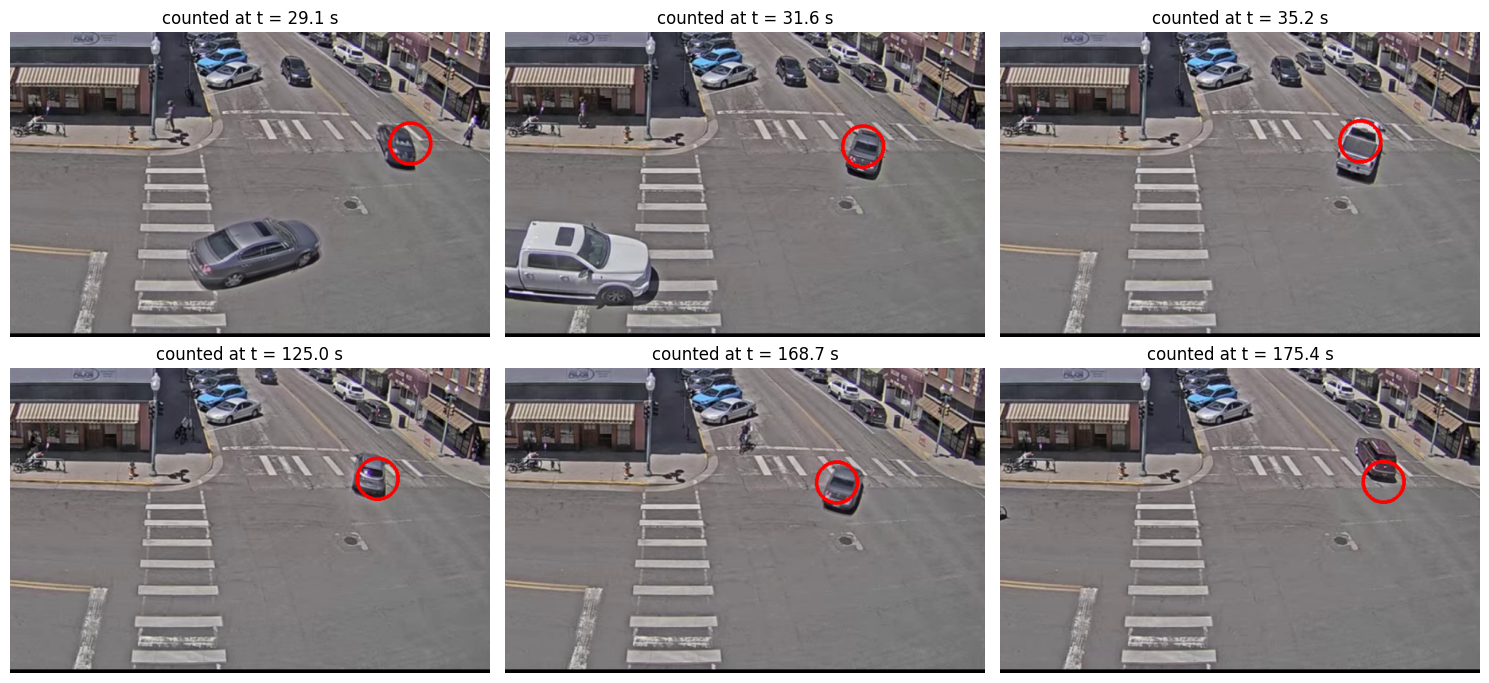

In [6]:
import matplotlib.pyplot as plt

def show_counted(video):
    events = COUNT_EVENTS.get(video, [])
    cap = cv.VideoCapture(video)
    fig, axes = plt.subplots(2, 3, figsize=(15, 7))
    for ax in axes.ravel():
        ax.axis("off")
    for ax, (f, x, y) in zip(axes.ravel(), events):
        cap.set(cv.CAP_PROP_POS_FRAMES, f)
        ok, frame = cap.read()
        cv.circle(frame, (x, y), 28, (0, 0, 255), 3)
        ax.imshow(cv.cvtColor(frame[180:600, 380:1040], cv.COLOR_BGR2RGB))
        ax.set_title(f"counted at t = {f / 25:.1f} s")
    cap.release()
    plt.tight_layout()
    plt.show()

show_counted("Traffic_Laramie_1.mp4")

The table compares the count with the hand count. A count is correct when it falls within 3 seconds of a car on the hand list.

In [7]:
by_hand = {"Traffic_Laramie_1.mp4": [29, 31, 35, 125, 169, 175], "Traffic_Laramie_2.mp4": []}   # seconds at which each car crosses the yellow gate
counted = {v: [f / 25 for f, x, y in COUNT_EVENTS.get(v, [])] for v in by_hand}

def compare(found, truth, tolerance=3.0):
    left = list(truth)
    correct = 0
    for t in sorted(found):
        near = [u for u in left if abs(u - t) <= tolerance]
        if near:
            left.remove(min(near, key=lambda u: abs(u - t)))
            correct += 1
    return {"Counted": len(found), "Correct": correct, "False counts": len(found) - correct, "Missed": len(left)}

pd.DataFrame([{"Video": v, "By hand": len(by_hand[v]), **compare(counted[v], by_hand[v])} for v in by_hand])

,Video,By hand,Counted,Correct,False counts,Missed
0,Traffic_Laramie_1.mp4,6,6,6,0,0
1,Traffic_Laramie_2.mp4,0,0,0,0,0
